<a href="https://www.kaggle.com/code/actuaryabhishekroy/playground-series-s5-e10-xg-boost?scriptVersionId=273208716" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
# Importing Libraries to play with the data:)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Libraries for developing the Model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# To remove warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
data_train = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")
data_test = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

# Exploratory Data Analysis

## Data Description
1. **id** - Primary Key
2. **road_type** - Type of road; one of (highway', 'urban', 'rural')
3. **num_lanes** - Number of lanes on the road segment (1, 2, 3, 4)
4. **curvature** - Measure of road curvature; 0.0 means straight, 1.0 means highly curved
5. **speed_limit** - Legal speed limit in miles per hour
6. **lighting** - Lighting conditions; one of ('daylight', 'night', 'dim')
7. **weather** - Weather condition at the time; one of ('clear', 'rainy', 'foggy')
8. **road_signs_present** - Indicates whether road signs are present (True/False)
9. **public_road** - Indicates whether the road is public or privately owned
10. **time_of_day** - Time of day; one of ('morning', 'afternoon', 'night')
11. **holiday** - Whether the record falls on a public holiday (True/False)
12. **school_season** - Whether the record falls within an active school period (True/False)
13. **num_reported_accidents** - Number of previously reported accidents on this road segment
14. **accident_risk** - Model-generated accident risk score between 0.0 (low risk) and 1.0 (high risk)

In [4]:
data_train.head(10)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
5,5,highway,3,0.54,70,night,foggy,True,False,morning,False,True,0,0.61
6,6,highway,1,0.04,45,night,foggy,False,True,morning,True,False,2,0.20
7,7,highway,2,0.33,45,daylight,clear,False,True,evening,False,True,0,0.16
8,8,rural,3,0.63,25,dim,clear,True,False,evening,True,True,2,0.18
9,9,urban,4,0.38,45,dim,clear,True,True,afternoon,True,True,2,0.15


In [5]:
data_test.head(10)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3
5,517759,highway,2,0.52,25,night,rainy,True,True,morning,False,True,1
6,517760,rural,4,0.17,70,dim,clear,True,False,afternoon,True,True,0
7,517761,urban,3,0.62,25,daylight,clear,False,True,afternoon,True,False,0
8,517762,highway,3,0.93,45,dim,rainy,True,True,evening,True,False,2
9,517763,urban,1,0.97,35,daylight,clear,True,True,evening,False,True,2


In [6]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [7]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      172585 non-null  int64  
 1   road_type               172585 non-null  object 
 2   num_lanes               172585 non-null  int64  
 3   curvature               172585 non-null  float64
 4   speed_limit             172585 non-null  int64  
 5   lighting                172585 non-null  object 
 6   weather                 172585 non-null  object 
 7   road_signs_present      172585 non-null  bool   
 8   public_road             172585 non-null  bool   
 9   time_of_day             172585 non-null  object 
 10  holiday                 172585 non-null  bool   
 11  school_season           172585 non-null  bool   
 12  num_reported_accidents  172585 non-null  int64  
dtypes: bool(4), float64(1), int64(4), object(4)
memory usage: 12.5+ MB


In [8]:
print("Training data: ", data_train.shape)
print("Testing data: ", data_test.shape)

Training data:  (517754, 14)
Testing data:  (172585, 13)


In [9]:
data_train.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [10]:
data_test.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents
count,172585.000000,172585.000000,172585.000000,172585.000000,172585.000000
mean,604046.000000,2.494046,0.487263,46.102761,1.186059
std,49821.142441,1.119148,0.272343,15.787077,0.897161
min,517754.000000,1.000000,0.000000,25.000000,0.000000
25%,560900.000000,1.000000,0.260000,35.000000,1.000000
50%,604046.000000,2.000000,0.510000,45.000000,1.000000
75%,647192.000000,3.000000,0.710000,60.000000,2.000000
max,690338.000000,4.000000,1.000000,70.000000,7.000000


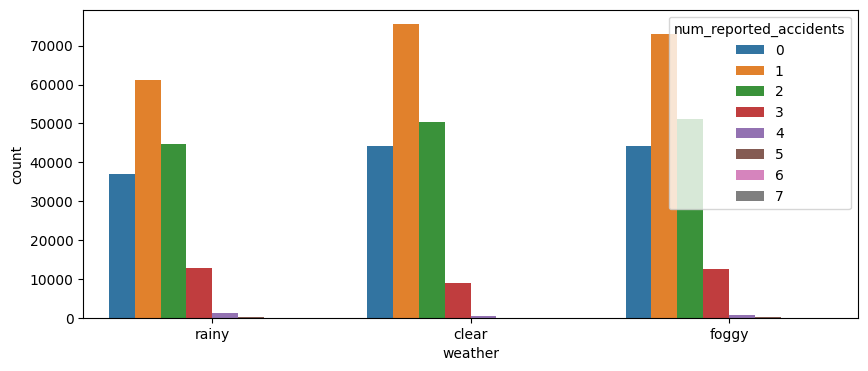

In [11]:
plt.figure(figsize=(10, 4))
sns.countplot(x = "weather", hue = "num_reported_accidents", data = data_train);

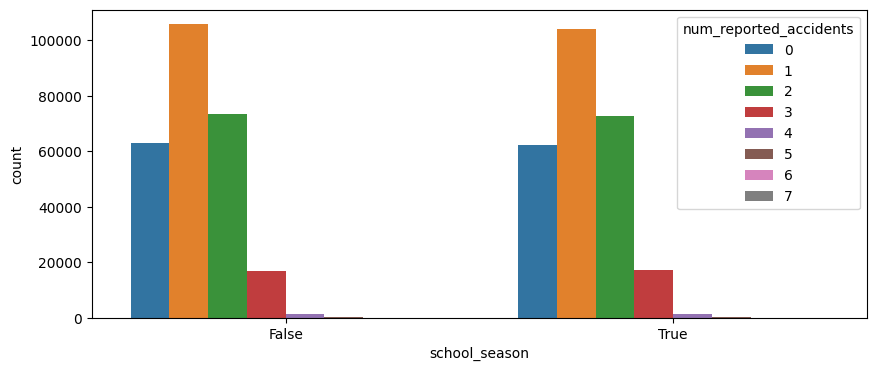

In [12]:
plt.figure(figsize=(10, 4))
sns.countplot(x = "school_season", hue = "num_reported_accidents", data = data_train);

<Axes: >

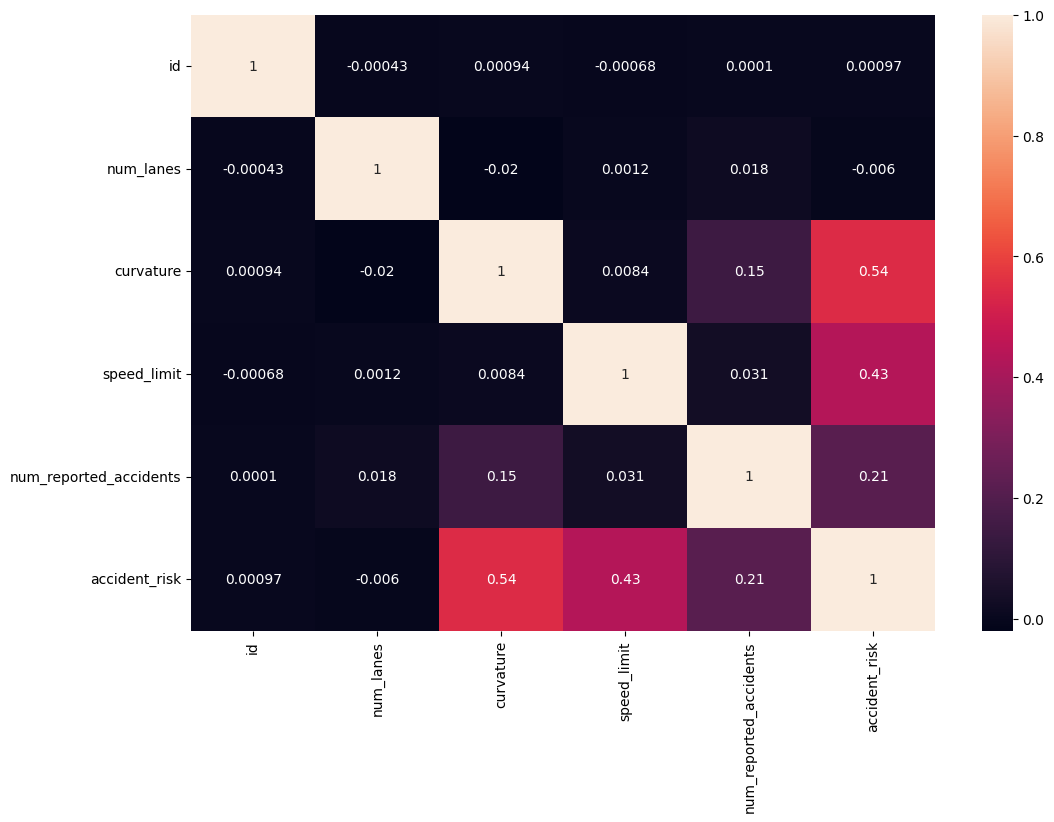

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_train.select_dtypes(include=['number']).corr(), annot=True)

**curvature, speed_limit and num_reported_accidents** are highly positively correlated with accident_risk

# Adding Features

In [14]:
data_train["curvature_accident_score"] = data_train["curvature"] * data_train["num_reported_accidents"]
data_train["speed_accident_score"] = data_train["speed_limit"] * data_train["num_reported_accidents"]
data_train["speed_accident_score"] = np.log1p(data_train["speed_accident_score"])

data_test["curvature_accident_score"] = data_test["curvature"] * data_test["num_reported_accidents"]
data_test["speed_accident_score"] = data_test["speed_limit"] * data_test["num_reported_accidents"]
data_test["speed_accident_score"] = np.log1p(data_test["speed_accident_score"])

In [15]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        517754 non-null  int64  
 1   road_type                 517754 non-null  object 
 2   num_lanes                 517754 non-null  int64  
 3   curvature                 517754 non-null  float64
 4   speed_limit               517754 non-null  int64  
 5   lighting                  517754 non-null  object 
 6   weather                   517754 non-null  object 
 7   road_signs_present        517754 non-null  bool   
 8   public_road               517754 non-null  bool   
 9   time_of_day               517754 non-null  object 
 10  holiday                   517754 non-null  bool   
 11  school_season             517754 non-null  bool   
 12  num_reported_accidents    517754 non-null  int64  
 13  accident_risk             517754 non-null  f

In [16]:
data_train.describe()

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk,curvature_accident_score,speed_accident_score
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377,0.616002,3.147271
std,149462.849974,1.120434,0.272563,15.788521,0.895961,0.166417,0.682438,1.839532
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000,0.020000,3.258097
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000,0.430000,3.828641
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000,0.860000,4.262680
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000,5.940000,6.196444


<Axes: >

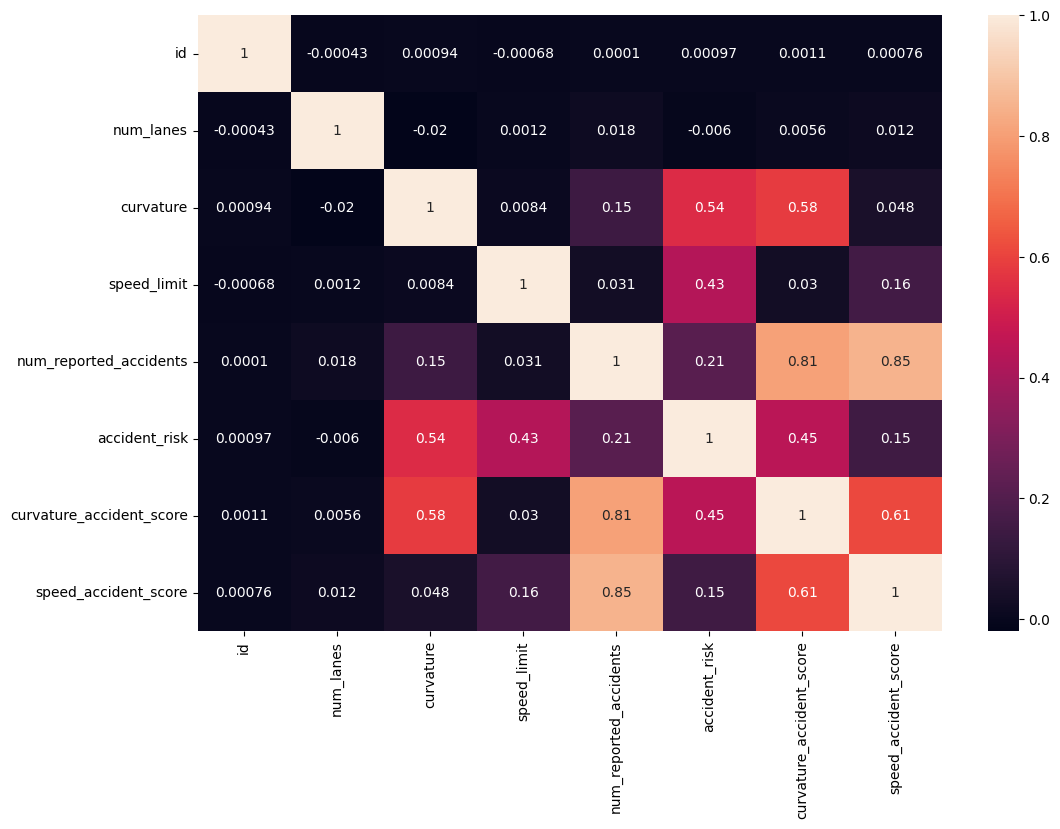

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_train.select_dtypes(include=['number']).corr(), annot=True)

# Preparing Data for the model

In [18]:
x_train = data_train.drop(["accident_risk"], axis = 1)
y_train = data_train["accident_risk"]
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(data_test, drop_first=True)

In [19]:
# Dropping id field - Unique for every record, making difficult for the model to build relationship
x_train = x_train.drop(columns=["id"])
x_test = x_test.drop(columns=["id"])

In [20]:
x_train.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,curvature_accident_score,speed_accident_score,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,time_of_day_evening,time_of_day_morning
0,2,0.06,35,False,True,False,True,1,0.06,3.583519,False,True,False,False,False,True,False,False
1,4,0.99,35,True,False,True,True,0,0.00,0.000000,False,True,False,False,False,False,True,False
2,4,0.63,70,False,True,True,False,2,1.26,4.948760,True,False,True,False,False,False,False,True
3,4,0.07,35,True,True,False,False,1,0.07,3.583519,False,False,True,False,False,True,False,True
4,1,0.58,60,False,False,True,False,1,0.58,4.110874,True,False,False,False,True,False,True,False


In [21]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   num_lanes                 517754 non-null  int64  
 1   curvature                 517754 non-null  float64
 2   speed_limit               517754 non-null  int64  
 3   road_signs_present        517754 non-null  bool   
 4   public_road               517754 non-null  bool   
 5   holiday                   517754 non-null  bool   
 6   school_season             517754 non-null  bool   
 7   num_reported_accidents    517754 non-null  int64  
 8   curvature_accident_score  517754 non-null  float64
 9   speed_accident_score      517754 non-null  float64
 10  road_type_rural           517754 non-null  bool   
 11  road_type_urban           517754 non-null  bool   
 12  lighting_dim              517754 non-null  bool   
 13  lighting_night            517754 non-null  b

# XG Boost Regressor

In [22]:
import xgboost as xgb
from xgboost import XGBRegressor

In [23]:
# Base model
xgb_base_model = XGBRegressor(objective='reg:squarederror', random_state=42)

In [24]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 9],
    'learning_rate': [0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 0.9],
    'min_child_weight': [4, 5, 6],  # controls overfitting
    'reg_lambda': [1.5, 2],      # L2 regularization
    'reg_alpha': [0, 0.1]      # L1 regularization
}

In [25]:
# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=xgb_base_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # use 'neg_mean_squared_error' for MSE optimization
    cv=3,                  # 3-fold cross validation
    verbose=1,
    n_jobs=-1              # use all CPU cores
)

In [26]:
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9],
                         'learning_rate': [0.05], 'max_depth': [8, 9],
                         'min_child_weight': [4, 5, 6],
                         'n_estimators': [200, 300], 'reg_alpha': [0, 0.1],
                         'reg_lambda': [1.5, 2], 'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [27]:
print("Best Parameters:", grid_search.best_params_)
print("Best MSE Score (CV):", round(grid_search.best_score_, 3))

Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 6, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 2, 'subsample': 0.8}
Best MSE Score (CV): -0.003


In [28]:
# Using Best parameter
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    min_child_weight = 6,
    colsample_bytree=0.9,
    reg_lambda = 2,
    reg_alpha = 0.1,
    random_state=42
)

In [29]:
xgb_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=6, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [30]:
y_train_pred = xgb_model.predict(x_train)
y_test_pred = xgb_model.predict(x_test)

In [31]:
print("RMSE score for Training data: ", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2 score for Training data: ", r2_score(y_train, y_train_pred))

RMSE score for Training data:  0.05526612606563551
R2 score for Training data:  0.8897133811219763


# Predicted File

In [32]:
res = pd.DataFrame({"id": data_test["id"], "accident_risk": y_test_pred.round(3)})
res.to_csv("submission.csv", index = False)